In [1]:
import os
import sys

# sys.path.append(os.path.join("/srv/sferraro/choreographer/"))
os.environ["MUJOCO_GL"] = "egl"

from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

# from custom_robosuite_tasks import *

CAMERAS = ["agentview", "frontview"]
size=(64,64)

env = CustomLift(
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names=CAMERAS,
                camera_depths=True,
                # render_visual_mesh=False,
                cube_minsize=(0.04, 0.04, 0.04),
                camera_segmentations="element",
                camera_heights= size[0],  # image h|eight
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [2]:
# move camera to agentview2 

cam_mover = CM(env, camera=CAMERAS[0])
(start_cam_pos, start_cam_quat) = cam_mover.get_camera_pose()
start_cam_pos += [0.2, 0.0, 0.5]

cam_mover.set_camera_pose(pos=start_cam_pos)

In [3]:
action = [0,0,0,0,0,0,0,0]
env_state, rew, done, info = env.step(action)

init_qpos = [-0.3, 0.85, 0, -2.2, 0, 3, 0.75]
env.robots[0].set_robot_joint_positions(init_qpos)
env.robots[0].controller.update_initial_joints(init_qpos)
env.robots[0].controller.reset_goal()

env_state = env._get_observations(force_update=True)

def state_extraction(cameras, env_state, _env):

    rgb = {}
    depth = {}
    seg = {}
    
    for camera in cameras:
        rgb[camera] = env_state[camera + "_image"][::-1].transpose(2, 0, 1)
        depth[camera] = CU.get_real_depth_map(sim=_env.sim, depth_map=env_state[camera + "_depth"][::-1].transpose(2, 0, 1))
        # depth[camera] = env_state[camera + "_depth"][::-1].transpose(2, 0, 1)

        # obtain world coordinates from the segmentation mask

        seg[camera] = env_state[
            camera + "_segmentation_" + "element"
        ][::-1].transpose(2, 0, 1)

    return  rgb, depth, seg

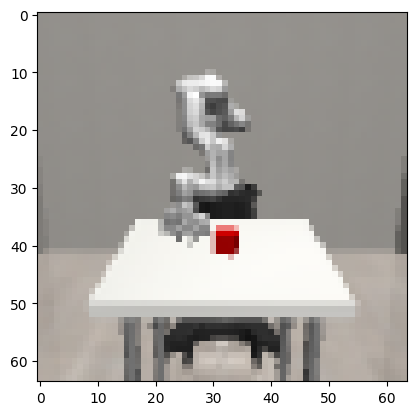

In [4]:
import matplotlib.pyplot as plt

rgbs, depth, seg = state_extraction(CAMERAS, env_state, env)

id = 1

plt.imshow(rgbs[CAMERAS[id]].transpose(1,2,0))

from PIL import Image
im = Image.fromarray(rgbs[CAMERAS[id]].transpose(1,2,0))
im.save("panda.png")

In [5]:
# constants
TASK = 'open_drawer'
DATA_FOLDER ='peract_colab/data'
EPISODES_FOLDER = 'colab_dataset/open_drawer/all_variations/episodes'
EPISODE_FOLDER = 'episode%d'
LOW_DIM_SIZE = 4   # {left_finger_joint, right_finger_joint, gripper_open, timestep}
IMAGE_SIZE =  64  # 128x128 - if you want to use higher voxel resolutions like 200^3, you might want to regenerate the dataset with larger images
VARIATION_DESCRIPTIONS_PKL = 'variation_descriptions.pkl' # the pkl file that contains language goals for each demonstration
EPISODE_LENGTH = 10 # max steps for agents
DEMO_AUGMENTATION_EVERY_N = 10 # sample n-th frame in demo
ROTATION_RESOLUTION = 5 # degree increments per axis

# settings
VOXEL_SIZES = [64] # 100x100x100 voxels
NUM_LATENTS = 512 # PerceiverIO latents
SCENE_BOUNDS = [-0.3, -0.5, 0.6, 0.7, 0.5, 1.6] # [x_min, y_min, z_min, x_max, y_max, z_max] - the metric volume to be voxelized
BATCH_SIZE = 1 
NUM_DEMOS = 8 # total number of training demonstrations to use while training PerAct
NUM_TEST = 2 # episodes to evaluate on

In [6]:
print(env_state.keys())

odict_keys(['robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'agentview_depth', 'agentview_segmentation_element', 'frontview_image', 'frontview_depth', 'frontview_segmentation_element', 'cube_pos', 'cube_quat', 'gripper_to_cube_pos', 'robot0_proprio-state', 'object-state'])


In [51]:
import voxel
import torch

class PinholeModel:
    def __init__(self, k_matrix, opengl=True):
        self.k_matrix = k_matrix
        self.opengl = opengl

    def uvd_to_xyz(self, u, v, d):
        fx = self.k_matrix[0][0]
        fy = self.k_matrix[1][1]
        cx = self.k_matrix[0][2]
        cy = self.k_matrix[1][2]

        x_over_z = (u - cx) / fx
        y_over_z = (v - cy) / fy

        z = torch.tensor(d.copy())
        x = x_over_z * z
        y = y_over_z * z
        return x, y, z
    
    
def coords_to_frame(coords, frame):
    """
    convert coordinates to the camera frame, i.e. as if
    the coordinate system of the camera is eye
    """
    coords = coords.permute(1,2,0)
    print(coords.shape)
    coords = torch.cat(
        [coords, torch.ones(coords.shape[0], 1, 1, device=coords.device)], dim=-1
    )
    frame = frame.unsqueeze(0).repeat(coords.shape[0], 1, 1)
    print(frame.shape)
    coords = torch.bmm(coords, frame.transpose(-2, -1)).squeeze(1)[..., :3]

    # assume coords as 3,W,H
    #p1 = t0_1 + R0_1*p0
    # coords = coords.permute(1,2,0)
    
    # t = frame[0:3, -1].unsqueeze(0).unsqueeze(0).repeat(coords.shape[0], coords.shape[1], 1)
    # R = frame[:3, :3].unsqueeze(0).unsqueeze(0).repeat(coords.shape[0], coords.shape[1], 1, 1)
    # print(R.shape)
    
    # coords = t + torch.bmm(coords, R)
    # 
    return coords


def _norm_rgb(x):
    return (x.float() / 255.0) * 2.0 - 1.0
    
def _preprocess_inputs(rgb, pcd):
    
    print(rgb.shape)
    print(pcd.shape)
    rgb = torch.tensor(rgb.copy(), device="cuda:0").unsqueeze(0).unsqueeze(0)
    pcd = pcd.squeeze(1).unsqueeze(0).unsqueeze(0)
    print(rgb.shape)
    print(pcd.shape)
    
    rgb = voxel.stack_on_channel(rgb)
    pcd = voxel.stack_on_channel(pcd)
    rgb = _norm_rgb(rgb)
    
    return rgb, pcd

In [52]:
import torch
from copy import deepcopy

from robosuite.utils.camera_utils import get_camera_intrinsic_matrix, get_camera_extrinsic_matrix
K = {}
R = {}

for cam in CAMERAS: 
    K[cam] = get_camera_intrinsic_matrix(
            sim=env.sim, camera_name=cam, camera_height=size[0], camera_width=size[1]
        )
    R[cam] = torch.tensor(get_camera_extrinsic_matrix(sim=env.sim, camera_name=cam), device="cuda")

u = [[x]*size[1] for x in range(size[0])]

u = torch.tensor(u)
v = u.T

cam_model = {}
obs = []
pcds = []

for i, cam in enumerate(CAMERAS):
    # fig = plt.figure()
    # ax = fig.add_subplot(projection='3d')
    
    cam_model[cam] = PinholeModel(K[cam])
    x, y, z = cam_model[cam].uvd_to_xyz(u, v, depth[cam])
    pcd = torch.stack((x, y, z), dim=0).to(device="cuda")

    pcd = coords_to_frame(pcd.squeeze(1), R[cam])

    rgb, p = _preprocess_inputs(rgbs[cam], pcd)
    
    obs.append([rgb, p])
    pcds.append(p)

    # ax.scatter(x, y, z)

torch.Size([64, 64, 3])


RuntimeError: Sizes of tensors must match except in dimension 2. Expected size 64 but got size 1 for tensor number 1 in the list.

In [9]:
import torch
import numpy as np

device = "cuda:0"

# initialize voxelizer
vox_grid = voxel.VoxelGrid(
    coord_bounds=SCENE_BOUNDS,
    voxel_size=VOXEL_SIZES[0],
    device=device,
    batch_size=BATCH_SIZE,
    feature_size=3,
    max_num_coords=np.prod([IMAGE_SIZE, IMAGE_SIZE]) * len(CAMERAS),
)

# sample from dataset
# batch = next(train_data_iter)
# lang_goal = batch['lang_goal'][0][0][0]
# batch = {k: v.to(device) for k, v in batch.items() if type(v) == torch.Tensor}

# preprocess observations
print(len(obs))
# pcds = obs[:][1]

# flatten observations
bs = obs[0][0].shape[0]
pcd_flat = torch.cat([p.permute(0, 2, 3, 1).reshape(bs, -1, 3) for p in pcds], 1)

image_features = [o[0] for o in obs]
feat_size = image_features[0].shape[1]
flat_imag_features = torch.cat(
    [p.permute(0, 2, 3, 1).reshape(bs, -1, feat_size) for p in image_features], 1)

# tensorize scene bounds
bounds = torch.tensor(SCENE_BOUNDS, device=device).unsqueeze(0)

# voxelize!
voxel_grid = vox_grid.coords_to_bounding_voxel_grid(pcd_flat, 
                                                    coord_features=flat_imag_features, 
                                                    coord_bounds=bounds)

# swap to channels fist
vis_voxel_grid = voxel_grid.permute(0, 4, 1, 2, 3).detach().cpu().numpy()

# expert action voxel indicies
# vis_gt_coord = batch['trans_action_indicies'][:, -1, :3].int().detach().cpu().numpy()

2


/home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/OpenGL/images.py:142: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  return data.tostring()


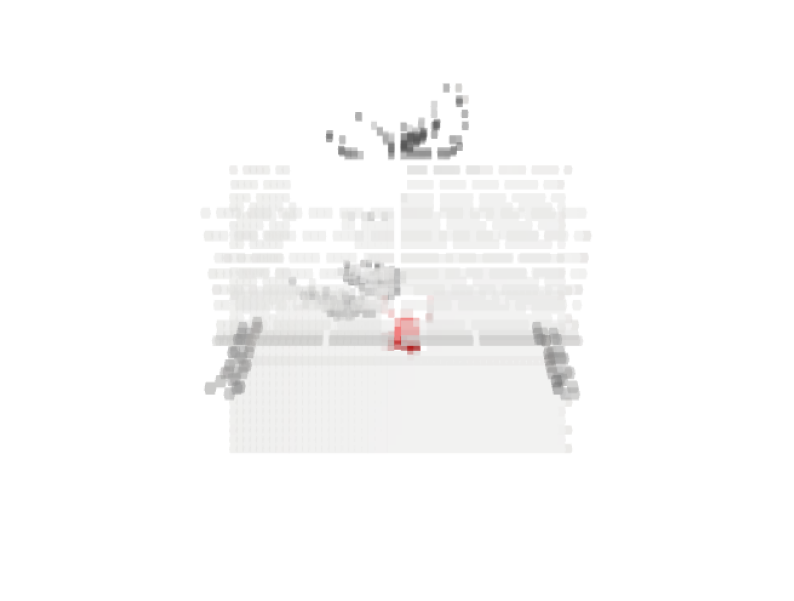

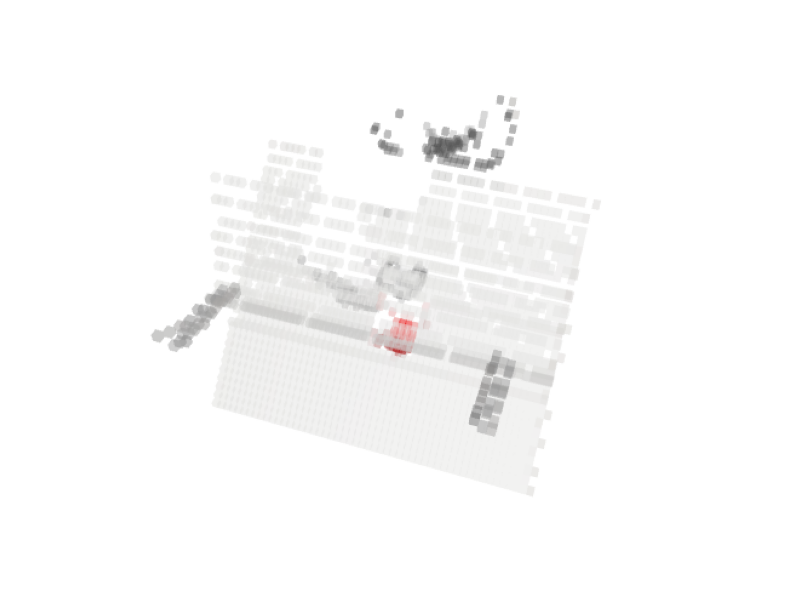

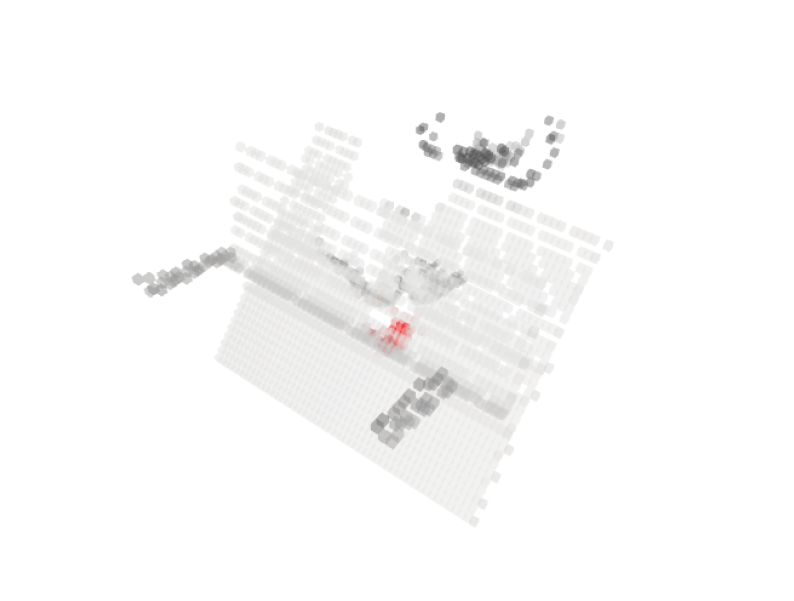

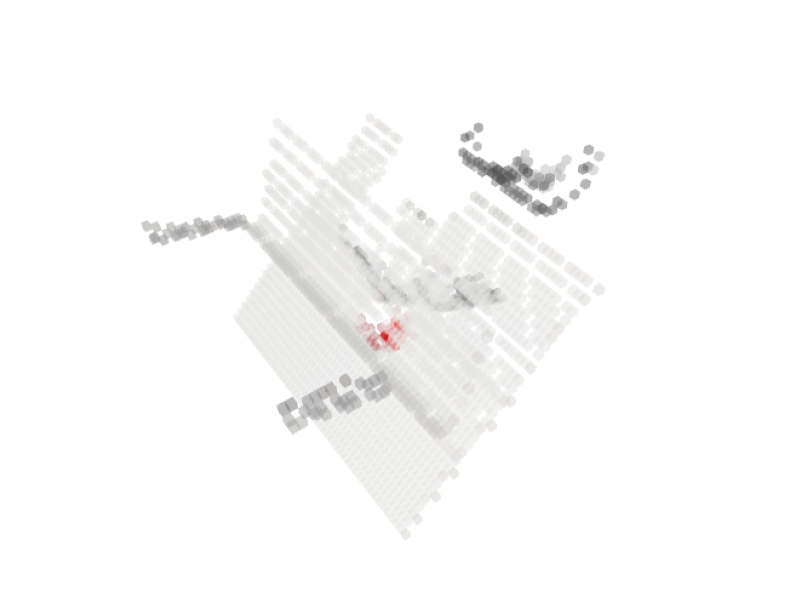

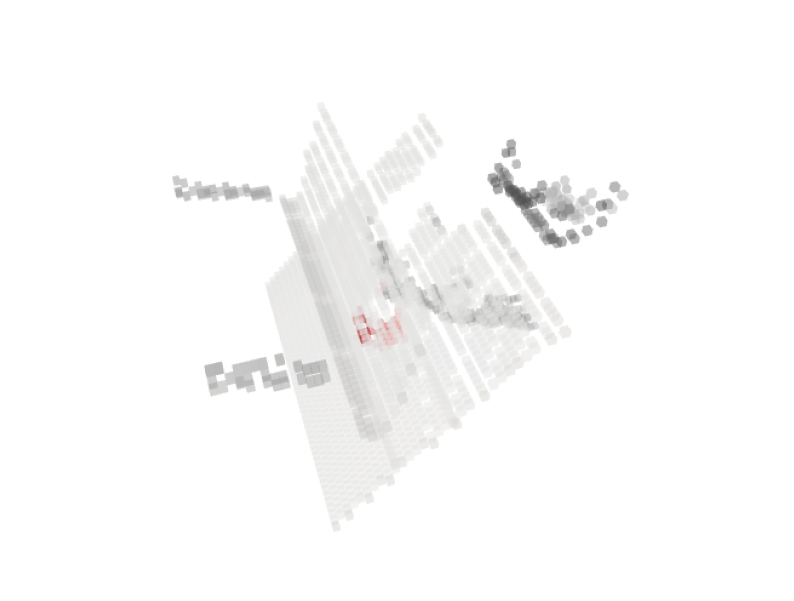

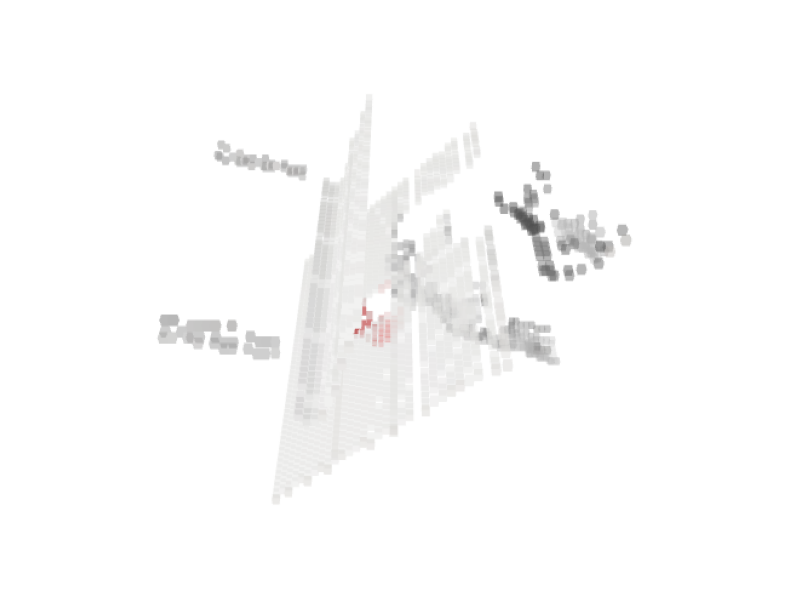

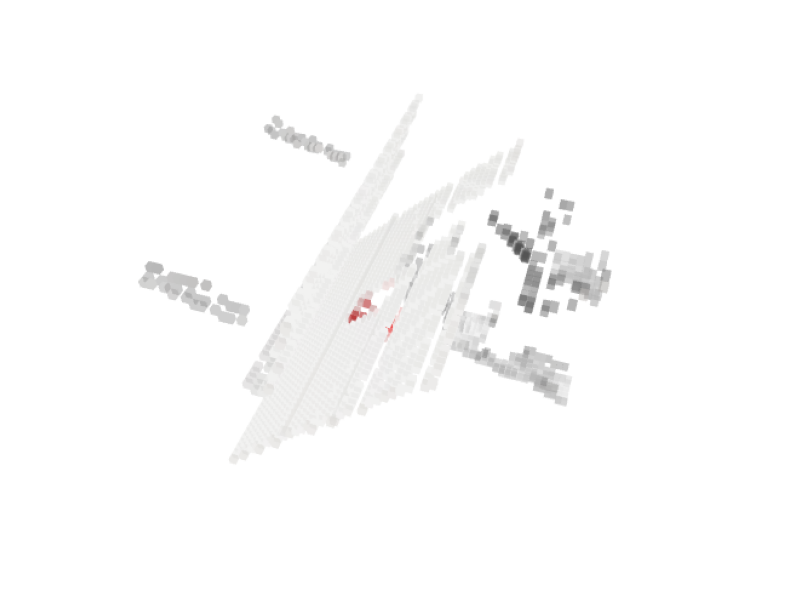

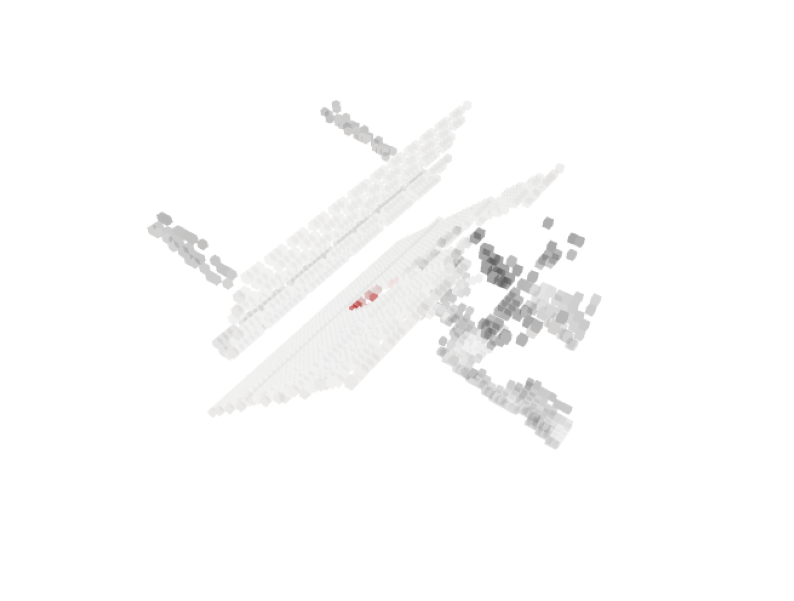

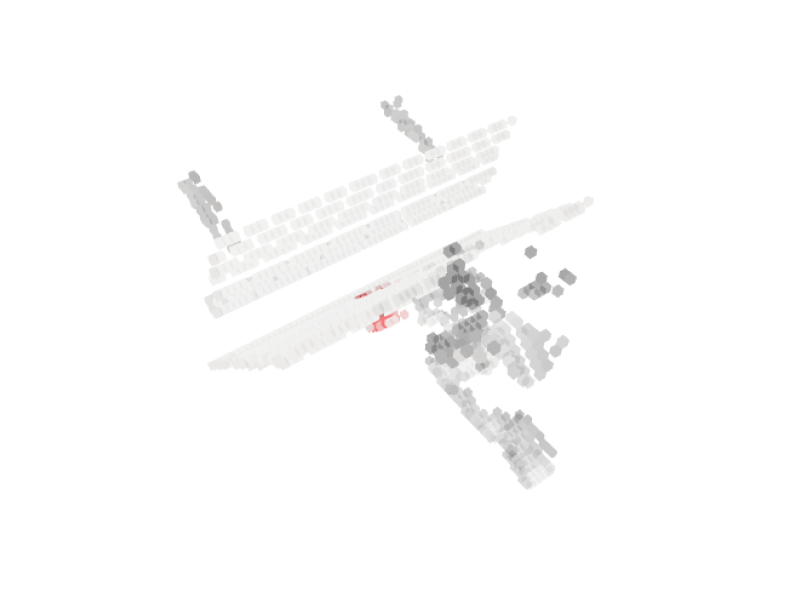

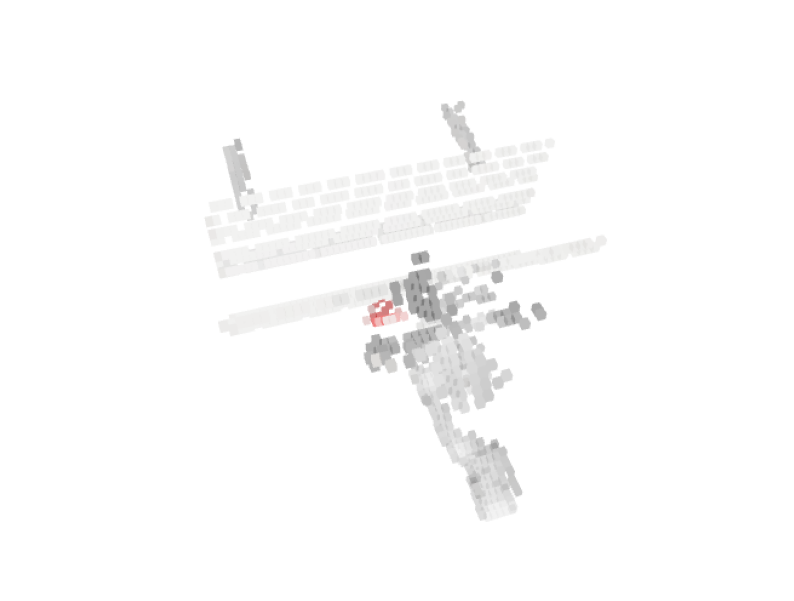

In [11]:
# %matplotlib widget
for o in range(10):
    rendered_img = voxel.visualise_voxel(vis_voxel_grid[0], voxel_size=0.045, rotation_amount=o*3.14/10)
    fig = plt.figure(figsize=(10, 10))
    plt.imshow(rendered_img)
    plt.axis('off')